In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#we are going to develop machine learning model which can predict the sales of different products based on the multiple attributes of the product 
#this is a Regression model because our target variable is continous variable 

In [3]:
#Loading the dataset 

In [4]:
bm=pd.read_csv(r'Downloads\Dataset18-Bigmart_sales.csv')

Exploratory Data Analysis EDA

In [5]:
bm.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
bm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
bm.shape

(8523, 12)

In [8]:
bm.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
bm.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [10]:
#Seperating Categorical and Numerical cols

In [11]:
cat_cols=bm.select_dtypes(include=['object']).columns.tolist()
cat_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [96]:
num_cols=bm.select_dtypes(exclude=['object']).columns.tolist()
num_cols

['Item_Weight',
 'Item_Fat_Content',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type',
 'Item_Outlet_Sales',
 'New_item_type',
 'Outlet_Years',
 'Item_Type_Breads',
 'Item_Type_Breakfast',
 'Item_Type_Canned',
 'Item_Type_Dairy',
 'Item_Type_Frozen Foods',
 'Item_Type_Fruits and Vegetables',
 'Item_Type_Hard Drinks',
 'Item_Type_Health and Hygiene',
 'Item_Type_Household',
 'Item_Type_Meat',
 'Item_Type_Others',
 'Item_Type_Seafood',
 'Item_Type_Snack Foods',
 'Item_Type_Soft Drinks',
 'Item_Type_Starchy Foods']

In [13]:
 #Target Variable Distribution 

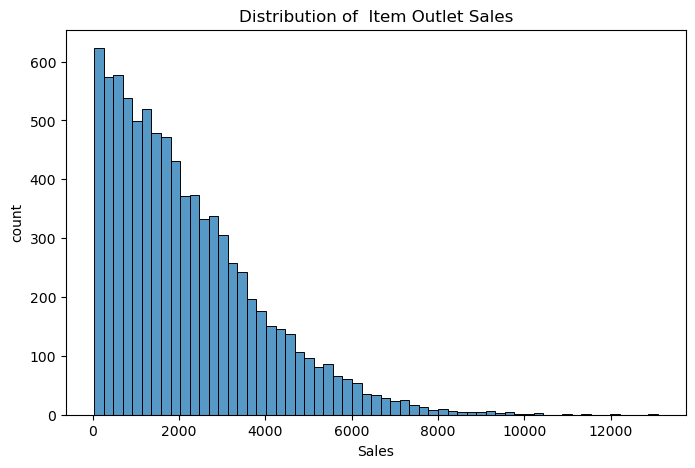

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(bm['Item_Outlet_Sales']),
plt.title("Distribution of  Item Outlet Sales")
plt.xlabel('Sales')
plt.ylabel('count')
plt.show()

<Axes: xlabel='Item_Weight', ylabel='Count'>

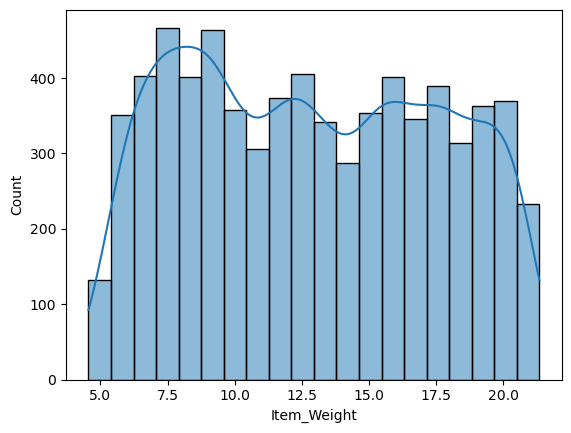

In [15]:
sns.histplot(bm['Item_Weight'],kde=True)

<Axes: xlabel='Item_Visibility', ylabel='Count'>

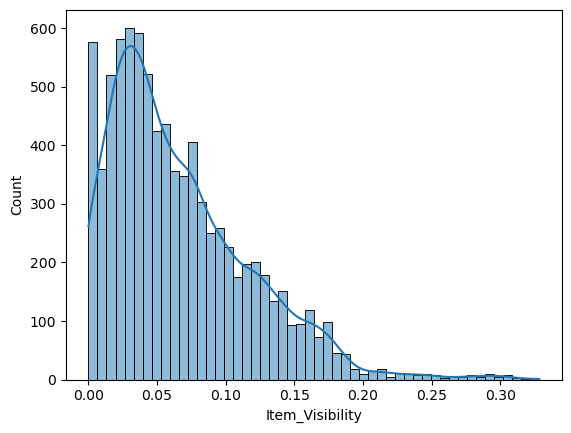

In [16]:
sns.histplot(bm['Item_Visibility'],kde=True)

In [17]:
zero=(bm['Item_Visibility']==0).sum()

In [18]:
zero

np.int64(526)

<Axes: xlabel='Item_MRP', ylabel='Count'>

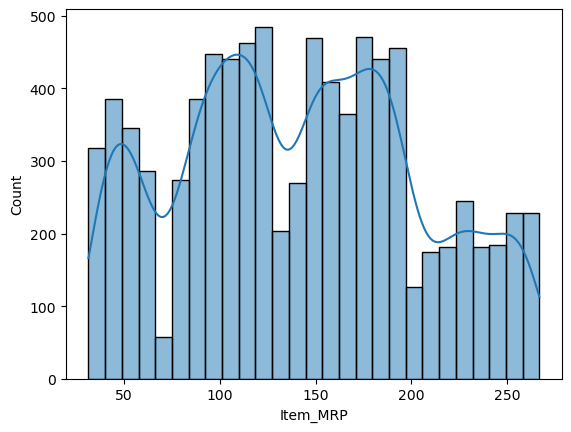

In [19]:
sns.histplot(bm['Item_MRP'],kde=True)

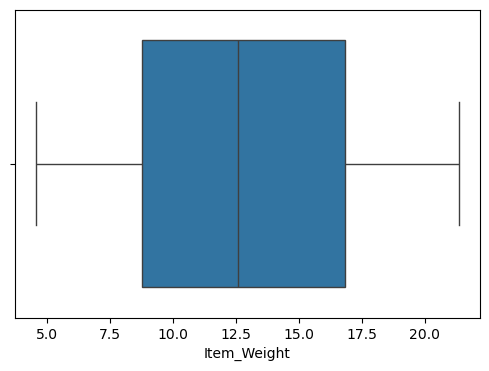

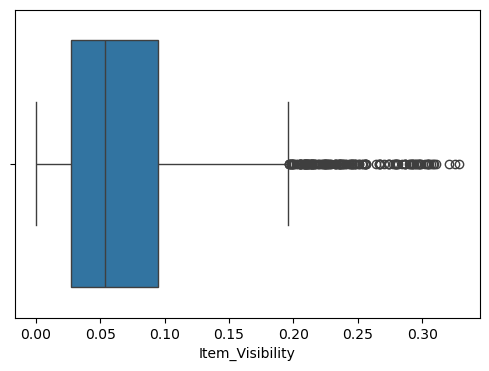

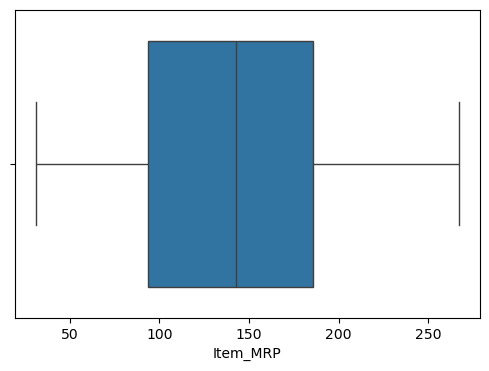

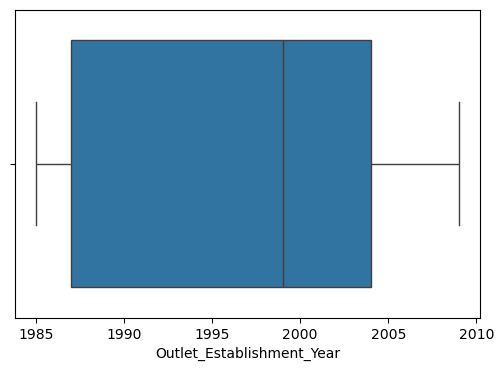

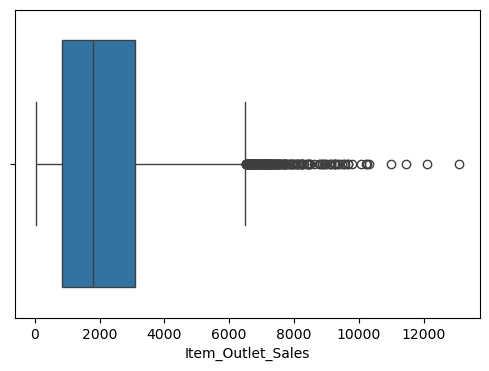

In [20]:
for col in num_cols:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = bm[col])

Text(0, 0.5, 'Outlet Sales')

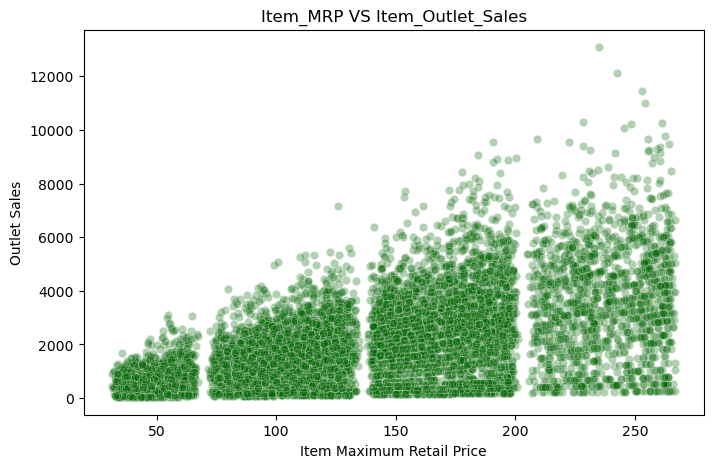

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Item_MRP',y='Item_Outlet_Sales',data=bm,alpha=0.3,color='darkgreen')
plt.title("Item_MRP VS Item_Outlet_Sales")
plt.xlabel('Item Maximum Retail Price')
plt.ylabel('Outlet Sales')

<Axes: >

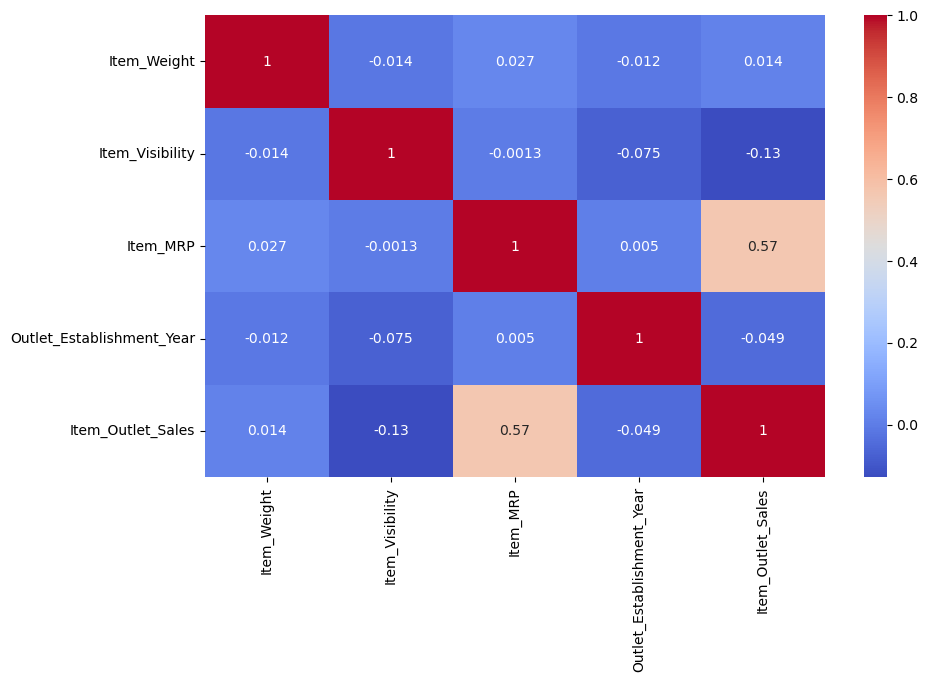

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(bm[num_cols].corr(),annot=True,cmap='coolwarm')

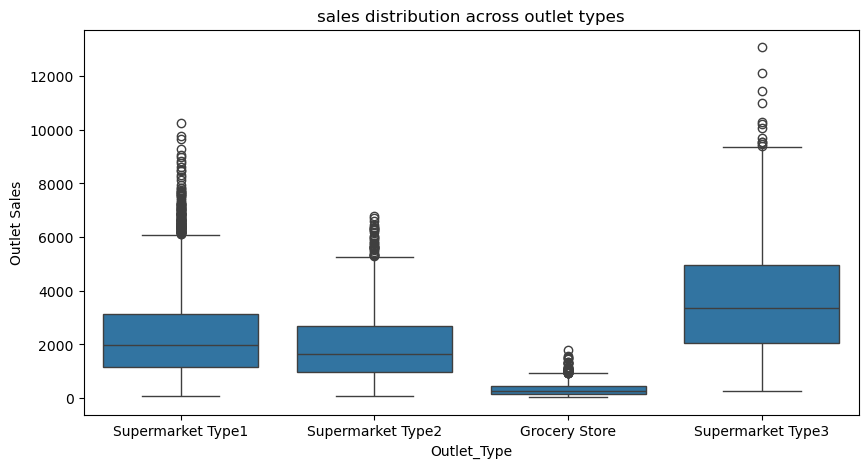

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Outlet_Type',y='Item_Outlet_Sales',data=bm)
plt.title("sales distribution across outlet types")
plt.xlabel('Outlet_Type')
plt.ylabel('Outlet Sales')
plt.show()


In [24]:
for col in cat_cols:
    print(bm[col].value_counts())
    print('--------------------------------------------------------------------------')

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64
--------------------------------------------------------------------------
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
-----------------------

In [25]:
numeric_cols=['Item_Weight','Item_Visibility','Item_MRP','Item_Outlet_Sales']
for col in numeric_cols:
    Q1=bm[col].quantile(0.25)
    Q3=bm[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=bm[(bm[col]<lower_bound) | (bm[col]>upper_bound)]
    print(f"{col}:found {len(outliers)}outliers")

Item_Weight:found 0outliers
Item_Visibility:found 144outliers
Item_MRP:found 0outliers
Item_Outlet_Sales:found 186outliers


Data Cleaning and preprocessing

In [26]:
#Handling the Missing values
# imputing item_weight based on item_identifier mean 

In [27]:
item_weight_mean=bm.pivot_table(values='Item_Weight',columns='Item_Identifier',aggfunc='mean')

missing_weights=bm["Item_Weight"].isnull()

bm.loc[missing_weights,"Item_Weight"]=bm.loc[missing_weights,"Item_Identifier"].apply(lambda x : item_weight_mean[x].values[0] if x in item_weight_mean else bm['Item_Weight'].mean())

In [28]:
item_weight_mean

Item_Identifier,DRA12,DRA24,DRA59,DRB01,DRB13,DRB24,DRB25,DRB48,DRC01,DRC12,...,NCZ05,NCZ06,NCZ17,NCZ18,NCZ29,NCZ30,NCZ41,NCZ42,NCZ53,NCZ54
Item_Weight,11.6,19.35,8.27,7.39,6.115,8.785,12.3,16.75,5.92,17.85,...,8.485,19.6,12.15,7.825,15.0,6.59,19.85,10.5,9.6,14.65


In [29]:
# Imputing outlet size based on outlet type mode

In [30]:
outlet_size_mode=bm.pivot_table(values='Outlet_Size',columns='Outlet_Type', aggfunc=lambda x: x.mode()[0])
outlet_size_mode

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [31]:
missing_sizes=bm['Outlet_Size'].isnull()
bm.loc[missing_sizes,'Outlet_Size']=bm.loc[missing_sizes,'Outlet_Type'].apply(lambda x : outlet_size_mode[x])

In [32]:
bm.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [33]:
# Fixing inconsistent Categories in item fat content

In [34]:
bm['Item_Fat_Content']=bm['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [35]:
bm['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [36]:
#Handling the zero values in item visibility 

In [37]:
bm['Item_Visibility']=bm['Item_Visibility'].replace(0,np.nan)
bm['Item_Visibility']=bm['Item_Visibility'].fillna(bm.groupby('Item_Identifier')['Item_Visibility'].transform('mean'))

<Axes: xlabel='Item_Visibility', ylabel='Count'>

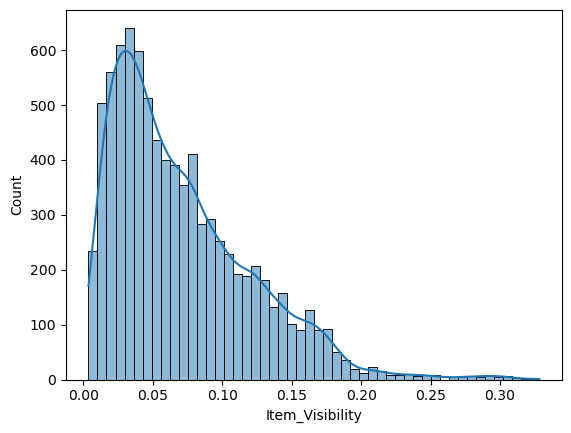

In [38]:
sns.histplot(bm['Item_Visibility'],kde=True)

In [39]:
zero=(bm['Item_Visibility']==0).sum()

In [40]:
zero

np.int64(0)

FEATURE ENGINEERING

In [42]:
bm['New_item_type']=bm['Item_Identifier'].apply(lambda x : x[:2])
bm['New_item_type']


0       FD
1       DR
2       FD
3       FD
4       NC
        ..
8518    FD
8519    FD
8520    NC
8521    FD
8522    DR
Name: New_item_type, Length: 8523, dtype: object

In [43]:
bm['New_item_type']=bm['New_item_type'].map({'FD':'Food','NC':'Non-Consumable','DR':'Drinks'})
bm['New_item_type'].value_counts()

New_item_type
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64

In [44]:
bm['Outlet_Years']=2026-bm['Outlet_Establishment_Year']

In [101]:
bm.loc[bm["New_item_type"]=='Non-Consumable','Item_Fat_Content']='Non - Edible'

In [102]:
bm['Item_Fat_Content'].value_counts()

Item_Fat_Content
0    3918
1    3006
2    1599
Name: count, dtype: int64

In [47]:
bm=bm.drop(columns=['Outlet_Establishment_Year'])

In [48]:
bm=bm.drop(columns=["Item_Broad_Category"])

In [49]:
bm=bm.drop(columns=['Item_Identifier','Outlet_Identifier'])

LABEL ENCODING 

In [51]:
bm['Item_Fat_Content']=bm['Item_Fat_Content'].map({'Low Fat':0,'Regular':1,'Non - Edible':2})

In [52]:
bm['Outlet_Size']=bm['Outlet_Size'].map({'Small':0,'Medium':1,'High':2})

In [53]:
bm['Outlet_Location_Type']=bm['Outlet_Location_Type'].map({'Tier 1':0,'Tier 2':1,'Tier 3':2})

In [54]:
bm['New_item_type']=bm['New_item_type'].map({'Food':0,'Drinks':1,'Non-Consumable':2})

In [55]:
bm['Outlet_Type']=bm['Outlet_Type'].map({'Grocery Store':0,'Supermarket Type1':1,'Supermarket Type2':2,'Supermarket Type3':3})

In [56]:
bm=pd.get_dummies(bm,columns=['Item_Type'],drop_first=True)

In [57]:
bm.head(1)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_item_type,Outlet_Years,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,9.3,0,0.016047,249.8092,1,0,1,3735.138,0,27,...,False,False,False,False,False,False,False,False,False,False


In [58]:
bm=bm.astype({col: int for col in bm.select_dtypes(include=["bool"]).columns})

FEATURE SCALING 

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
cols=['Item_Weight','Item_Visibility','Item_MRP','Outlet_Years']
scaler = StandardScaler()
bm[cols]=scaler.fit_transform(bm[cols])

In [61]:
bm_cleaned=bm.copy()

In [62]:
bm_cleaned.head(2)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_item_type,Outlet_Years,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,-0.769777,0,-1.087303,1.747454,1,0,1,3735.1380,0,-0.139541,...,0,0,0,0,0,0,0,0,0,0
1,-1.497483,1,-1.023083,-1.489023,1,2,2,443.4228,1,-1.334103,...,0,0,0,0,0,0,0,0,1,0


In [63]:
#seperating the features 
x=bm.drop(columns=['Item_Outlet_Sales'])
y=bm['Item_Outlet_Sales']

In [65]:
y

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64

MODEL DEVELOPMENT

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_pred=lr.predict(x_test)

In [70]:
r2=r2_score(y_test,y_pred)
r2

0.5178633618942473

In [71]:
n=x_test.shape[0]
p=x_test.shape[1]
adj_r2=1-((1-r2) * (n-1)/(n-p-1))
adj_r2

0.5109756956355938

In [73]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
score=round(r2_score(y_test,y_pred) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred),2)
rmse=round(root_mean_squared_error(y_test,y_pred),2)
print("-------------------Linear Regression Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)
print('Root mean Squared error (RMSE)=',rmse)

-------------------Linear Regression Model --------------
r2_squared=  51.79 %
Mean Squard Error (MSE)= 1310432.95
Root mean Squared error (RMSE)= 1144.74


Ridge Regression

In [74]:
from sklearn.linear_model import Ridge,Lasso 
ridge_model=Ridge()
ridge_model.fit(x_train,y_train)
y_pred_ridge=ridge_model.predict(x_test)
score=round(r2_score(y_test,y_pred_ridge) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred_ridge),2)
rmse=round(root_mean_squared_error(y_test,y_pred_ridge),2)
print("-------------------Ridge Regression Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)
print('Root mean Squared error (RMSE)=',rmse)

-------------------Ridge Regression Model --------------
r2_squared=  51.79 %
Mean Squard Error (MSE)= 1310413.43
Root mean Squared error (RMSE)= 1144.73


Random Forest Regression

In [75]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=1000)
rf.fit(x_train,y_train)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
y_pred_rf=rf.predict(x_test)

In [77]:
rf=RandomForestRegressor(n_estimators=1000)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
score=round(r2_score(y_test,y_pred_rf) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred_rf),2)
rmse=round(root_mean_squared_error(y_test,y_pred_rf),2)
print("-------------------RandomForest Regressor Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)
print('Root mean Squared error (RMSE)=',rmse)

-------------------RandomForest Regressor Model --------------
r2_squared=  56.85 %
Mean Squard Error (MSE)= 1172866.36
Root mean Squared error (RMSE)= 1082.99


In [115]:
from sklearn.model_selection import RandomizedSearchCV

In [116]:
param_dist={'n_estimators':[50,100,150,200,300],'learning_rate':[0.01,0.05,0.1,0.2],'max_depth':[3,4,5,6,7],'subsample':[0.7,0.8,0.9,1.0],'colsample_bytree':[0.7,0.8,0.9,1.0]}
xgb=XGBRegressor(random_state=42)
xgb_tuned=RandomizedSearchCV(estimator=xgb,param_distributions=param_dist,n_iter=15,cv=3,scoring='neg_mean_squared_error',random_state=42,n_jobs=-1)

In [117]:
xgb_tuned.fit(x_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,n_iter,15
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [118]:
print("best parameters:",xgb_tuned.best_params_)

best parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


XGBoost Regression

In [119]:
from xgboost import XGBRegressor
from sklearn import metrics

In [120]:
regressor=XGBRegressor(n_estimators=300,learning_rate=0.01,max_depth=4,random_state=42,colsample_bytree=1.0,subsample=0.9)
regressor.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [121]:
y_pred_xgb=regressor.predict(x_test)

In [130]:
regressor=XGBRegressor(n_estimators=300,learning_rate=0.01,max_depth=4,random_state=42,colsample_bytree=1.0,subsample=0.9)
regressor.fit(x_train,y_train)
y_pred_xgb=regressor.predict(x_test)
score=round(r2_score(y_test,y_pred_xgb) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred_xgb),2)
rmse=round(root_mean_squared_error(y_test,y_pred_xgb),2)
mae_val=mean_absolute_error(y_test,y_pred_xgb)
y_train_pred=regressor.predict(x_train)
train_score=round(r2_score(y_train,y_train_pred)*100,2)
print("-------------------XGBRegressor Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)
print('Root mean Squared error (RMSE)=',rmse)
print(' mean absolute error (MAE)=',mae_val)
print("r2_squared_train= ",train_score,'%')

-------------------XGBRegressor Model --------------
r2_squared=  61.44 %
Mean Squard Error (MSE)= 1048139.47
Root mean Squared error (RMSE)= 1023.79
 mean absolute error (MAE)= 723.4724827392721
r2_squared_train=  61.03 %


Lasso Regression

In [82]:
lasso_model=Lasso()
lasso_model.fit(x_train,y_train)
y_pred_lasso=lasso_model.predict(x_test)
score=round(r2_score(y_test,y_pred_lasso) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred_lasso),2)
print("-------------------Lasso Regression Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)

-------------------Lasso Regression Model --------------
r2_squared=  51.88 %
Mean Squard Error (MSE)= 1307998.64


Decision Tree Regressor

In [83]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor()
dt_model.fit(x_train,y_train)
y_pred_dt=dt_model.predict(x_test)
score=round(r2_score(y_test,y_pred_dt) * 100 ,2)
mse= round(mean_squared_error(y_test,y_pred_dt),2)
print("-------------------Decision Tree Model --------------")
print("r2_squared= ",score,'%')
print('Mean Squard Error (MSE)=',mse)

-------------------Decision Tree Model --------------
r2_squared=  19.63 %
Mean Squard Error (MSE)= 2184452.4


Best Model cross Validation:

In [127]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(regressor,x,y,scoring='r2',cv=5)
scores

array([0.60556101, 0.58768629, 0.58010302, 0.60803805, 0.60627381])

In [128]:
print(f'accuracy of the model = {round(scores.mean()*100,2)}%')

accuracy of the model = 59.75%


In [86]:
importances=regressor.feature_importances_
feature_names=x.columns


In [87]:
importance_df=pd.DataFrame({'Feature': feature_names,'importance':importances}).sort_values(by='importance',ascending=False)

<Axes: xlabel='importance', ylabel='Feature'>

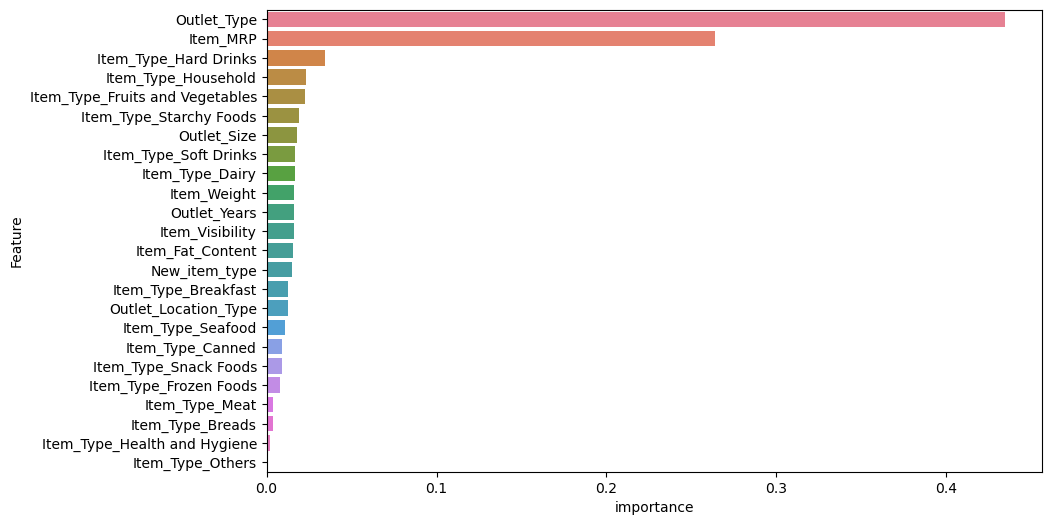

In [88]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance',y='Feature',data=importance_df,hue='Feature',legend=False)

In [89]:
new_sample={'Item_Weight':[9.41],'Item_Fat_Content':[0],'Item_Visibility':[0.63],'Outlet_Years':[20],'Outlet_Size':[1],'Item_MRP':[253],'Outlet_Location_Type':[0],'Outlet_Type':[1]}

In [90]:
unseen_df=pd.DataFrame(new_sample)
unseen_df

,Item_Weight,Item_Fat_Content,Item_Visibility,Outlet_Years,Outlet_Size,Item_MRP,Outlet_Location_Type,Outlet_Type
0,9.41,0,0.63,20,1,253,0,1


In [91]:
for col in x.columns:
    if col not in unseen_df.columns:
        unseen_df[col]=0

In [92]:
unseen_df=unseen_df[x.columns]

In [93]:
scaler=StandardScaler()

In [94]:
unseen_scaled=scaler.fit_transform(unseen_df)

In [95]:
predict=regressor.predict(unseen_scaled)
print('Sales Prediction by Model= ', predict[0])

Sales Prediction by Model=  307.43237


<Axes: >

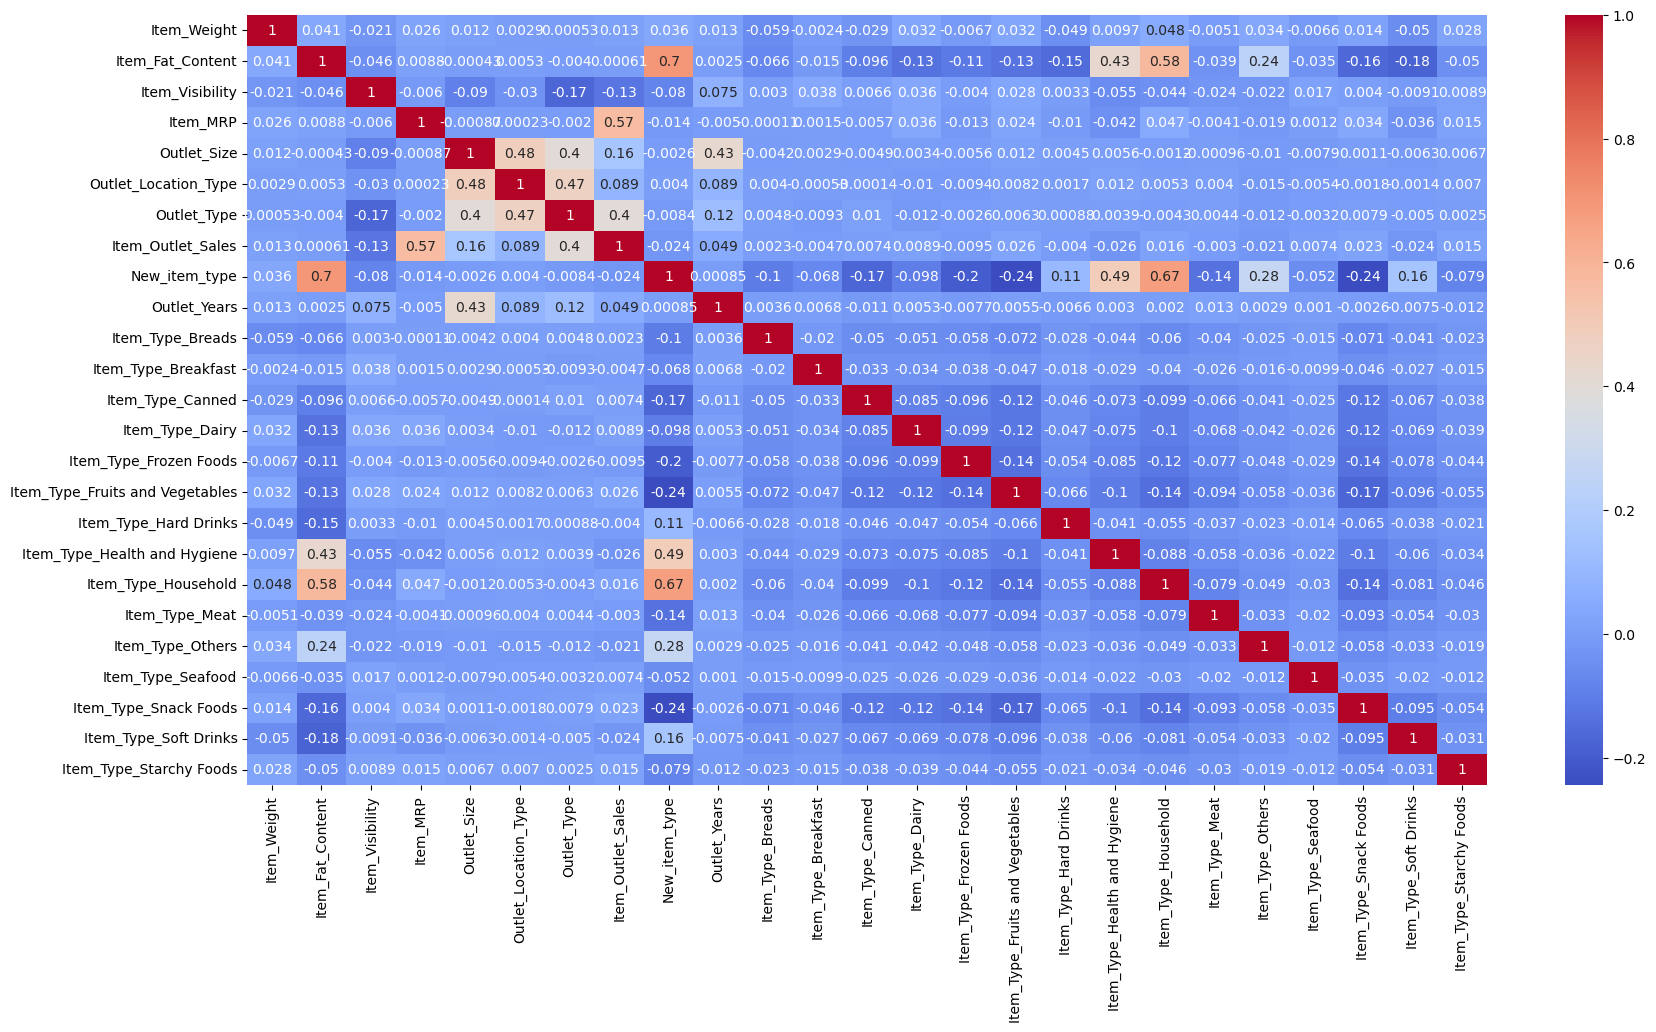

In [99]:
plt.figure(figsize=(20,10))
sns.heatmap(bm[num_cols].corr(),annot=True,cmap='coolwarm')